Для начала я загрузила данные, посмотрела первые строки, общую информацию о столбцах, статистику по числовым признакам и проверила наличие пропусков.Вижу, что пропусков нет, имеются неинформативные колонки. Приступаю к очистке данных: удалила строки с пропущенными значениями (dropna()),
посчитала количество дубликатов,
убрала повторяющиеся строки.

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/health_lifestyle_dataset.csv')

# Удаляю ненужные колонки, так как они неинформативны
df = df.drop(columns=['id'], errors='ignore')
# Очистка строковых данных
if 'gender' in df.columns:
    df['gender'] = df['gender'].astype(str).str.lower().str.strip()

num_cols = [
    'age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l',
    'calories_consumed', 'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol'
]

binary_cols = ['smoker', 'alcohol', 'family_history', 'disease_risk']

# Числовые признаки
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Бинарные признаки
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

# Категориальные признаки
if 'gender' in df.columns:
    df['gender'] = df['gender'].astype('category')

# Удаление пропусков и дубликатов

df = df.dropna(subset=num_cols)
df = df.drop_duplicates()

print("\n После удаления пропусков и дубликатов:")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
if 'disease_risk' in df.columns:
    print("Баланс классов (до удаления выбросов):")
    print(df['disease_risk'].value_counts(normalize=True))

# Удаляю выбросы по IQR (числовые признаки)
df_cleaned = df.copy()

for col in num_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[
        (df_cleaned[col] >= lower_bound) &
        (df_cleaned[col] <= upper_bound)
    ]

df_cleaned = df_cleaned.drop_duplicates()
print(f"\n После удаления выбросов: {df_cleaned.shape[0]} строк, {df_cleaned.shape[1]} столбцов")
if 'disease_risk' in df_cleaned.columns:
    print("Баланс классов (после удаления выбросов):")
    print(df_cleaned['disease_risk'].value_counts(normalize=True))

# Проверка и сохранение
# На всякий случай удаляю колонку 'id', если где-то появилась
df_cleaned = df_cleaned.drop(columns=['id'], errors='ignore')

print("\n Итоговая информация о данных:")
df_cleaned.info()
display(df_cleaned.describe())
# Сохраняю чистый набор без индекса
# Сохраняю очищенных данных
df_cleaned.to_csv('cleaned_data.csv',index=False)
print('Очистка данных завершена!')
# Предварительная проверка корреляции
corr = df_cleaned.corr(numeric_only=True)
if 'disease_risk' in corr.columns:
    print("\nКорреляция признаков с disease_risk:")
    display(corr['disease_risk'].sort_values(ascending=False))



 После удаления пропусков и дубликатов:
Строк: 100000, Столбцов: 14
Баланс классов (до удаления выбросов):
disease_risk
0    0.75179
1    0.24821
Name: proportion, dtype: float64

 После удаления выбросов: 100000 строк, 14 столбцов
Баланс классов (после удаления выбросов):
disease_risk
0    0.75179
1    0.24821
Name: proportion, dtype: float64

 Итоговая информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   age                100000 non-null  int64   
 1   gender             100000 non-null  category
 2   bmi                100000 non-null  float64 
 3   daily_steps        100000 non-null  int64   
 4   sleep_hours        100000 non-null  float64 
 5   water_intake_l     100000 non-null  float64 
 6   calories_consumed  100000 non-null  int64   
 7   alcohol            100000 non-null  int64   
 8   restin

,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,33.000000,23.500000,5729.00000,4.700000,1.600000,1906.000000,0.000000,62.000000,112.00000,74.000000,187.000000,0.000000,0.000000
50%,48.000000,29.000000,10468.00000,6.500000,2.800000,2603.000000,0.000000,74.000000,135.00000,89.000000,224.000000,0.000000,0.000000
75%,64.000000,34.500000,15229.00000,8.200000,3.900000,3299.000000,1.000000,87.000000,157.00000,105.000000,262.000000,1.000000,0.000000
max,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


Очистка данных завершена!

Корреляция признаков с disease_risk:


,disease_risk
disease_risk,1.000000
resting_hr,0.005437
bmi,0.003586
family_history,0.003225
calories_consumed,0.002737
sleep_hours,0.002582
age,0.001671
systolic_bp,0.001086
alcohol,0.000515
water_intake_l,-0.001902


Очистка данных завершена.

In [ ]:
#Проверяю как выглядит файл после очистки
df_cleaned.head(5)

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,56,male,20.5,4198,3.9,3.4,1602,0,97,161,111,240,0,0
1,69,female,33.3,14359,9.0,4.7,2346,1,68,116,65,207,0,0
2,46,male,31.6,1817,6.6,4.2,1643,1,90,123,99,296,0,0
3,32,female,38.2,15772,3.6,2.0,2460,0,71,165,95,175,0,0
4,60,female,33.6,6037,3.8,4.0,3756,1,98,139,61,294,0,0


Теперь перехожу к приведению данных в числовой формат, так как это необходимо для дальнейшего и правильного анализа

In [ ]:
import pandas as pd
import numpy as np
# Создаю для кодирования бинарных текстовых признаков
binary_mapping = {
    'yes': 1,
    'no': 0,
    'male': 1,
    'm': 1,
    'female': 0,
    'f': 0
}

# Кодирую все object/категориальные колонки
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object' or str(df_cleaned[col].dtype) == 'category':
        df_cleaned[col] = df_cleaned[col].str.lower().str.strip()  # нормализуем строки
        df_cleaned[col] = df_cleaned[col].map(binary_mapping)       # кодируем в 0/1
        df_cleaned[col] = df_cleaned[col].fillna(0).astype(int)    # пропуски заменяем на 0

# Проверяю, что все колонки числовые
for col in df_cleaned.columns:
    if not pd.api.types.is_numeric_dtype(df_cleaned[col]):
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0)

# Проверяю что получилось
print("Типы данных после кодирования:")
print(df_cleaned.dtypes)
print("\nПервые 5 строк:")
display(df_cleaned.head(5))
# Сохраняю финальный числовой датасет
df_cleaned.to_csv('/content/health_data_numeric_cleaned.csv', index=False)
print("\n Данные сохранены в 'health_data_numeric_cleaned.csv' — все признаки числовые, бинарные значения закодированы")


Типы данных после кодирования:
age                    int64
gender                 int64
bmi                  float64
daily_steps            int64
sleep_hours          float64
water_intake_l       float64
calories_consumed      int64
alcohol                int64
resting_hr             int64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
family_history         int64
disease_risk           int64
dtype: object

Первые 5 строк:


,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,56,1,20.5,4198,3.9,3.4,1602,0,97,161,111,240,0,0
1,69,0,33.3,14359,9.0,4.7,2346,1,68,116,65,207,0,0
2,46,1,31.6,1817,6.6,4.2,1643,1,90,123,99,296,0,0
3,32,0,38.2,15772,3.6,2.0,2460,0,71,165,95,175,0,0
4,60,0,33.6,6037,3.8,4.0,3756,1,98,139,61,294,0,0



 Данные сохранены в 'health_data_numeric_cleaned.csv' — все признаки числовые, бинарные значения закодированы


теперь нужно привести данные к одному типу



In [ ]:
#Проверяю в каком виде данные
df_cleaned.dtypes

,0
age,int64
gender,int64
bmi,float64
daily_steps,int64
sleep_hours,float64
water_intake_l,float64
calories_consumed,int64
alcohol,int64
resting_hr,int64
systolic_bp,int64


In [ ]:
df_cleaned.head(5)

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,56,1,20.5,4198,3.9,3.4,1602,0,97,161,111,240,0,0
1,69,0,33.3,14359,9.0,4.7,2346,1,68,116,65,207,0,0
2,46,1,31.6,1817,6.6,4.2,1643,1,90,123,99,296,0,0
3,32,0,38.2,15772,3.6,2.0,2460,0,71,165,95,175,0,0
4,60,0,33.6,6037,3.8,4.0,3756,1,98,139,61,294,0,0


In [ ]:
# Все данные корректны, приведены в числовой вид и закодированы. Перехожу к масштабированию
#Для масштабирования использую Min-Max Scaling (0–1) и Standard Scaling (Z-score)
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Беру очищенный DataFrame
df = df_cleaned.copy()

# Определяю числовые колонки
num_cols = df.select_dtypes(include='number').columns

# Min-Max Scaling

minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax_scaler.fit_transform(df_minmax[num_cols])

# Сохраняю
df_minmax.to_csv('/content/health_data_minmax_scaled.csv', index=False)
print("Min-Max масштабирование сохранено в 'health_data_minmax_scaled.csv'")

# Standard Scaling (Z-score)

standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = standard_scaler.fit_transform(df_standard[num_cols])

# Сохраняю
df_standard.to_csv('/content/health_data_standard_scaled.csv', index=False)
print("Standard (Z-score) масштабирование сохранено в 'health_data_standard_scaled.csv'")

# Проверка первых строк

print("\n Пример Min-Max масштабирования:")
display(df_minmax.head())

print("\n Пример Standard масштабирования:")
display(df_standard.head())


Min-Max масштабирование сохранено в 'health_data_minmax_scaled.csv'
Standard (Z-score) масштабирование сохранено в 'health_data_standard_scaled.csv'

 Пример Min-Max масштабирования:


,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,0.622951,1.0,0.113636,0.168325,0.128571,0.644444,0.143623,0.0,0.959184,0.797753,0.864407,0.604027,0.0,0.0
1,0.836066,0.0,0.695455,0.703142,0.857143,0.933333,0.409432,1.0,0.367347,0.292135,0.084746,0.382550,0.0,0.0
2,0.459016,1.0,0.618182,0.043002,0.514286,0.822222,0.158271,1.0,0.816327,0.370787,0.661017,0.979866,0.0,0.0
3,0.229508,0.0,0.918182,0.777515,0.085714,0.333333,0.450161,0.0,0.428571,0.842697,0.593220,0.167785,0.0,0.0
4,0.688525,0.0,0.709091,0.265119,0.114286,0.777778,0.913183,1.0,0.979592,0.550562,0.016949,0.966443,0.0,0.0



 Пример Standard масштабирования:


,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,0.417853,0.997363,-1.341930,-1.145573,-1.281848,0.499875,-1.240382,-0.654685,1.562891,1.018033,1.238900,0.362342,-0.653329,-0.574594
1,1.144651,-1.002643,0.672982,0.707405,1.240517,1.501933,-0.318774,1.527452,-0.447697,-0.715978,-1.412862,-0.399299,-0.653329,-0.574594
2,-0.141222,0.997363,0.405377,-1.579777,0.053522,1.116526,-1.189594,1.527452,1.077577,-0.446243,0.547136,1.654822,-0.653329,-0.574594
3,-0.923927,-1.002643,1.444316,0.965082,-1.430222,-0.579263,-0.177560,-0.654685,-0.239705,1.172167,0.316548,-1.137859,-0.653329,-0.574594
4,0.641484,-1.002643,0.720207,-0.810210,-1.331306,0.962363,1.427822,1.527452,1.632221,0.170294,-1.643450,1.608662,-0.653329,-0.574594


                        age    gender       bmi  daily_steps  sleep_hours  \
age                1.000000  0.000124  0.001198     0.004847     0.000437   
gender             0.000124  1.000000 -0.000379     0.001245    -0.003120   
bmi                0.001198 -0.000379  1.000000     0.001814     0.000922   
daily_steps        0.004847  0.001245  0.001814     1.000000    -0.001209   
sleep_hours        0.000437 -0.003120  0.000922    -0.001209     1.000000   
water_intake_l    -0.005644 -0.003173 -0.003634    -0.000898     0.001507   
calories_consumed -0.002684 -0.000580  0.002262     0.000306     0.001229   
alcohol           -0.000923  0.004643  0.002138     0.003456    -0.006332   
resting_hr         0.001460 -0.001730 -0.006327     0.004401     0.002628   
systolic_bp        0.000806  0.002609  0.000806    -0.002049     0.000180   
diastolic_bp       0.000178  0.000523 -0.003100    -0.003537     0.002243   
cholesterol        0.000747  0.001240  0.002045     0.000123     0.003051   

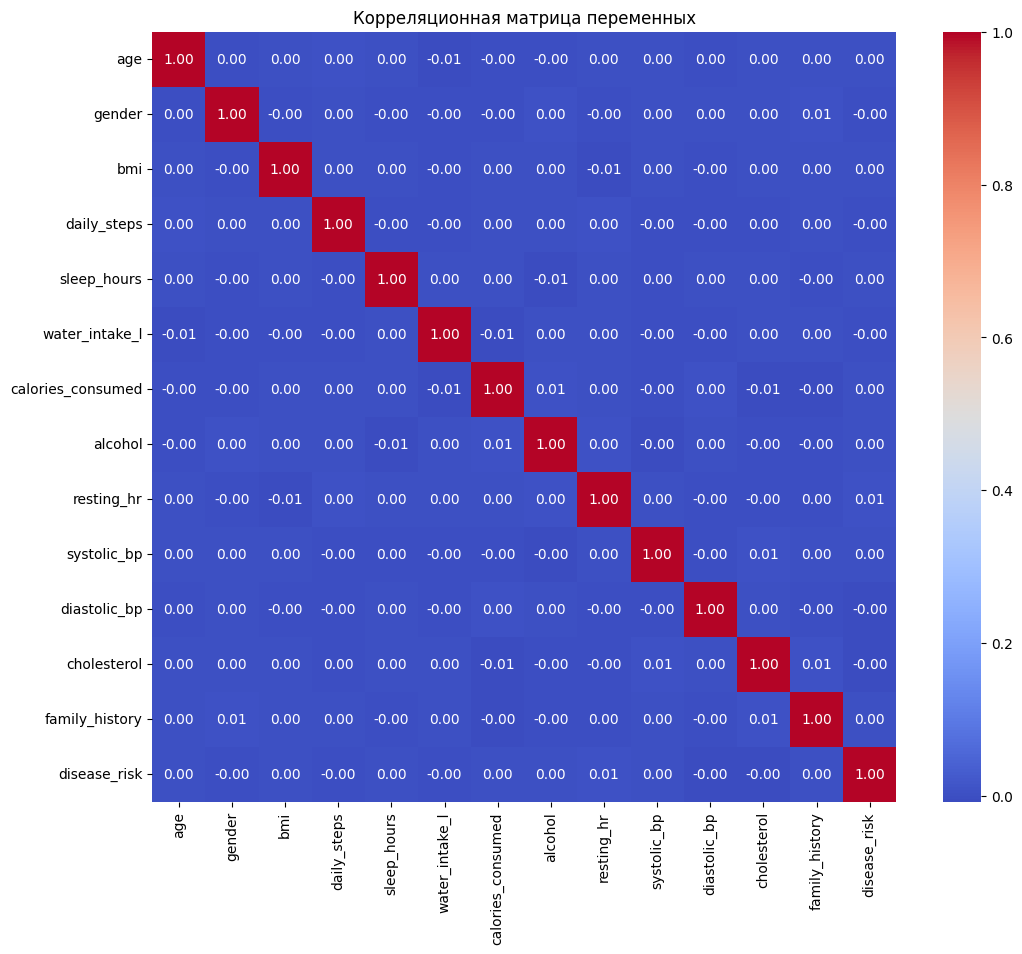

In [ ]:
#Все данные очищены, пришло время для матрицы корреляции, чтобы посмотреть как обстановка
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_corr = df_cleaned.copy()
# Вычисляю корреляционную матрицу
corr_matrix = df_corr.corr()

# Вывожу матрицу
print(corr_matrix)

# Визуализирую матрицу с помощью тепловой карты
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляционная матрица переменных")
plt.show()


Судя по матрице корреляции получилась крайне грустная картина. Я решила соединить систолическое и диастолическое давление в один показатель, так как они обычно идут в паре. Назову это "среднее давление или bpm"

Index(['age', 'gender', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l',
       'calories_consumed', 'alcohol', 'resting_hr', 'cholesterol',
       'family_history', 'disease_risk', 'bpm'],
      dtype='object')


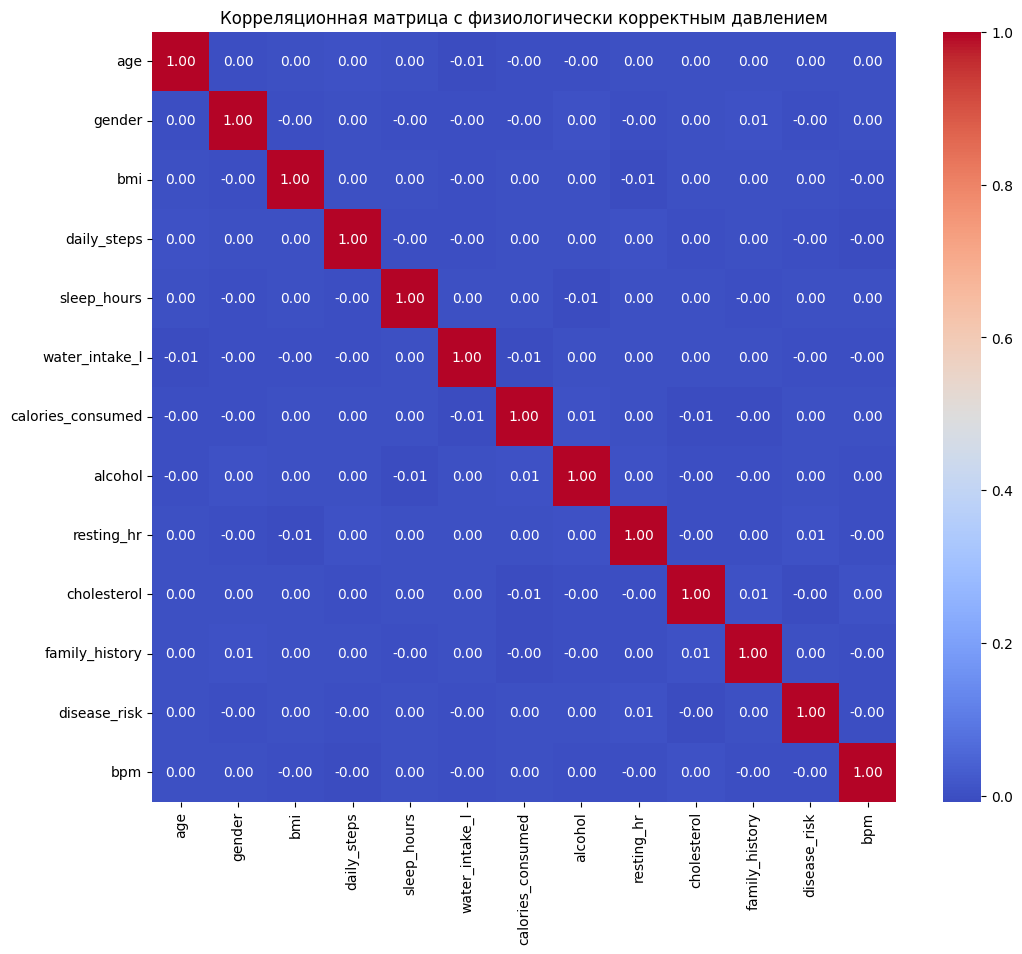

In [ ]:
# Создаю физиологически корректный признак MAP
df_cleaned['bpm'] = (df_cleaned['systolic_bp'] + 2 * df_cleaned['diastolic_bp']) / 3

# Убираю старые колонки
df_cleaned = df_cleaned.drop(columns=['systolic_bp', 'diastolic_bp'])

# Проверяю новые названия столбцов
print(df_cleaned.columns)

# Строю обновлённую корреляционную матрицу
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_cleaned.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляционная матрица с физиологически корректным давлением")
plt.show()


Картина сложилась не менее печальная и я решила преобразовать все значения во float

age                  float64
gender               float64
bmi                  float64
daily_steps          float64
sleep_hours          float64
water_intake_l       float64
calories_consumed    float64
alcohol              float64
resting_hr           float64
cholesterol          float64
family_history       float64
disease_risk         float64
bpm                  float64
dtype: object


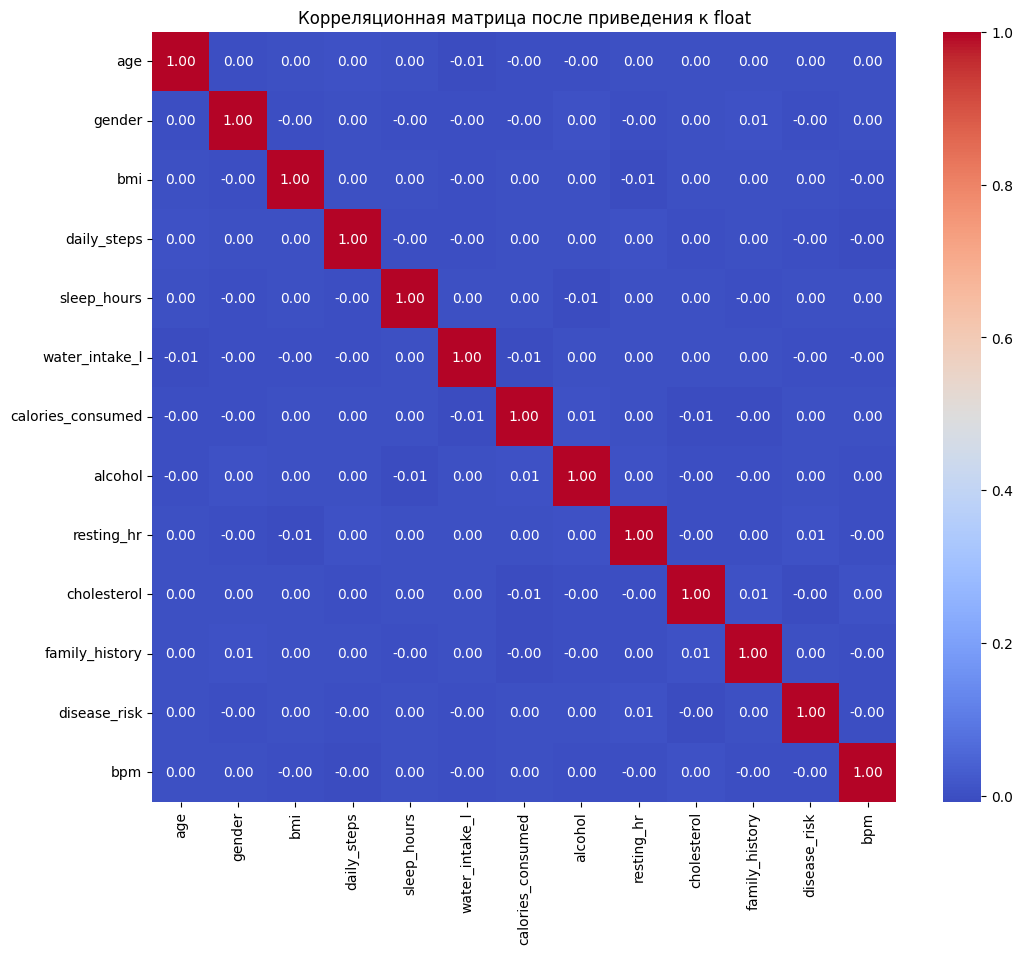

In [ ]:
# Привожу все значения к float
df_cleaned = df_cleaned.astype(float)

# Проверяю типы столбцов
print(df_cleaned.dtypes)

# Строю корреляционную матрицу заново
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_cleaned.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляционная матрица после приведения к float")
plt.show()


Ищу варианты взаимосвязей, чтобы улучшить матрицу корреляции и улучшить связь признаков

    Group  Max_corr  Min_corr
5    grp7  0.005630 -0.002684
18  grp20  0.005016  0.002045
2    grp4  0.005016  0.002045
16  grp18  0.005016 -0.003599
20  grp22  0.004847 -0.000923
0    grp1  0.004847 -0.004064
22  grp24  0.004586 -0.002002
9   grp11  0.003456 -0.006332
8   grp10  0.002651 -0.000393
12  grp14  0.002651  0.002651
3    grp5  0.002651 -0.000933
21  grp23  0.002651 -0.001877
11  grp13  0.002576 -0.005644
1    grp3  0.002262 -0.001209
17  grp19  0.002138 -0.003599
7    grp9  0.002138 -0.000923
13  grp15  0.001984  0.000124
19  grp21  0.001460 -0.001721
14  grp16  0.001240  0.000124
15  grp17  0.000747 -0.003599
4    grp6 -0.002684 -0.007590
10  grp12 -0.002684 -0.007590
6    grp8 -0.006332 -0.006332


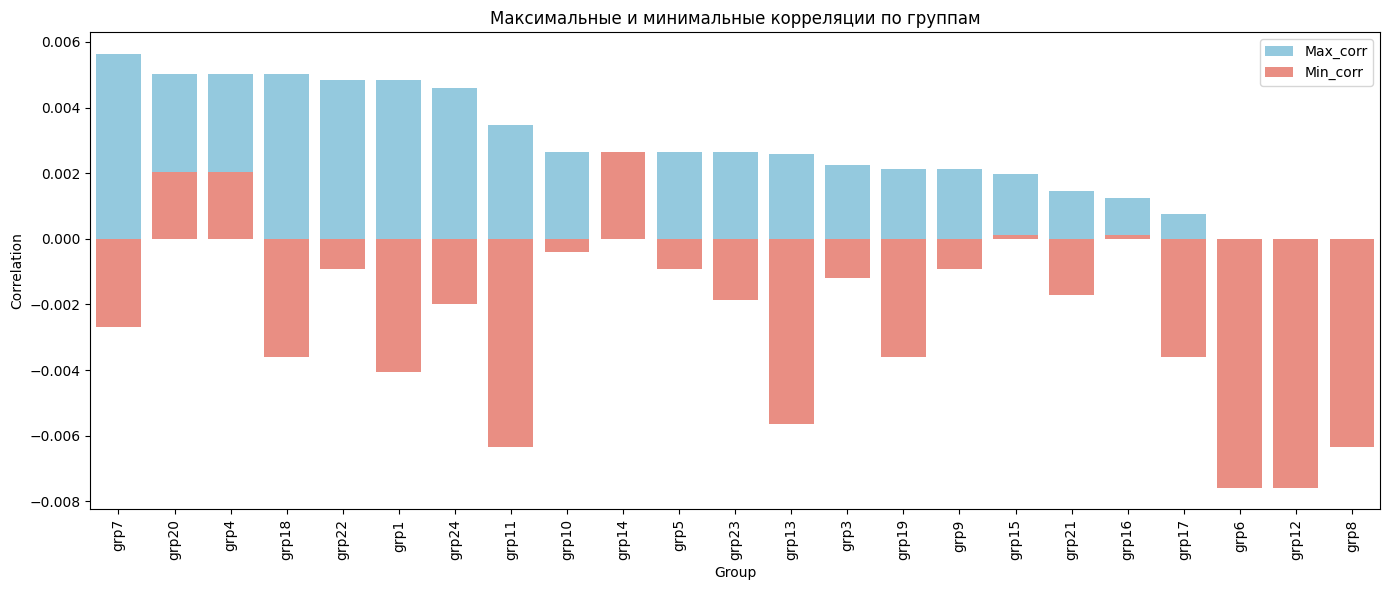

/tmp/ipython-input-3406501129.py:64: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,5))


<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

...

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Определяю группы колонок
groups = {
    'grp1': ['resting_hr', 'bpm', 'age', 'daily_steps'],
    'grp3': ['calories_consumed', 'daily_steps', 'bmi', 'sleep_hours'],
    'grp4': ['family_history', 'bmi', 'cholesterol'],
    'grp5': ['resting_hr', 'bpm', 'age', 'family_history'],
    'grp6': ['calories_consumed', 'water_intake_l', 'age'],
    'grp7': ['age', 'alcohol', 'calories_consumed'],
    'grp8': ['sleep_hours','alcohol'],
    'grp9': ['age','bmi','alcohol'],
    'grp10': ['family_history','age','bpm'],
    'grp11': ['alcohol','sleep_hours','daily_steps'],
    'grp12': ['calories_consumed', 'water_intake_l', 'age'],
    'grp13': ['water_intake_l','age','cholesterol'],
    'grp14': ['age','family_history'],
    'grp15': ['age','gender','bpm'],
    'grp16': ['age','gender','cholesterol'],
    'grp17': ['age','cholesterol','alcohol'],
    'grp18': ['family_history','cholesterol','alcohol','bpm'],
    'grp19': ['bmi','cholesterol','alcohol'],
    'grp20': ['bmi','cholesterol','family_history'],
    'grp21': ['resting_hr','cholesterol','age'],
    'grp22': ['age','daily_steps','alcohol'],
    'grp23': ['age','sleep_hours','bpm','family_history'],
    'grp24': ['bpm','cholesterol','bmi']
}

# Создаю таблицу с максимальными и минимальными корреляциями
max_corrs = []

for name, cols in groups.items():
    corr_matrix = df_cleaned[cols].corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    max_val = upper_tri.max().max()
    min_val = upper_tri.min().min()
    max_corrs.append({
        'Group': name,
        'Max_corr': max_val,
        'Min_corr': min_val
    })

max_corr_df = pd.DataFrame(max_corrs).sort_values(by='Max_corr', ascending=False)
print(max_corr_df)

#Barplot максимальных и минимальных корреляций по группам
plt.figure(figsize=(14, 6))
sns.barplot(x='Group', y='Max_corr', data=max_corr_df, color='skyblue', label='Max_corr')
sns.barplot(x='Group', y='Min_corr', data=max_corr_df, color='salmon', label='Min_corr')
plt.xticks(rotation=90)
plt.ylabel('Correlation')
plt.title('Максимальные и минимальные корреляции по группам')
plt.legend()
plt.tight_layout()
plt.show()

#Heatmap для каждой группы
for name, cols in groups.items():
    corr_matrix = df_cleaned[cols].corr()
    plt.figure(figsize=(6,5))


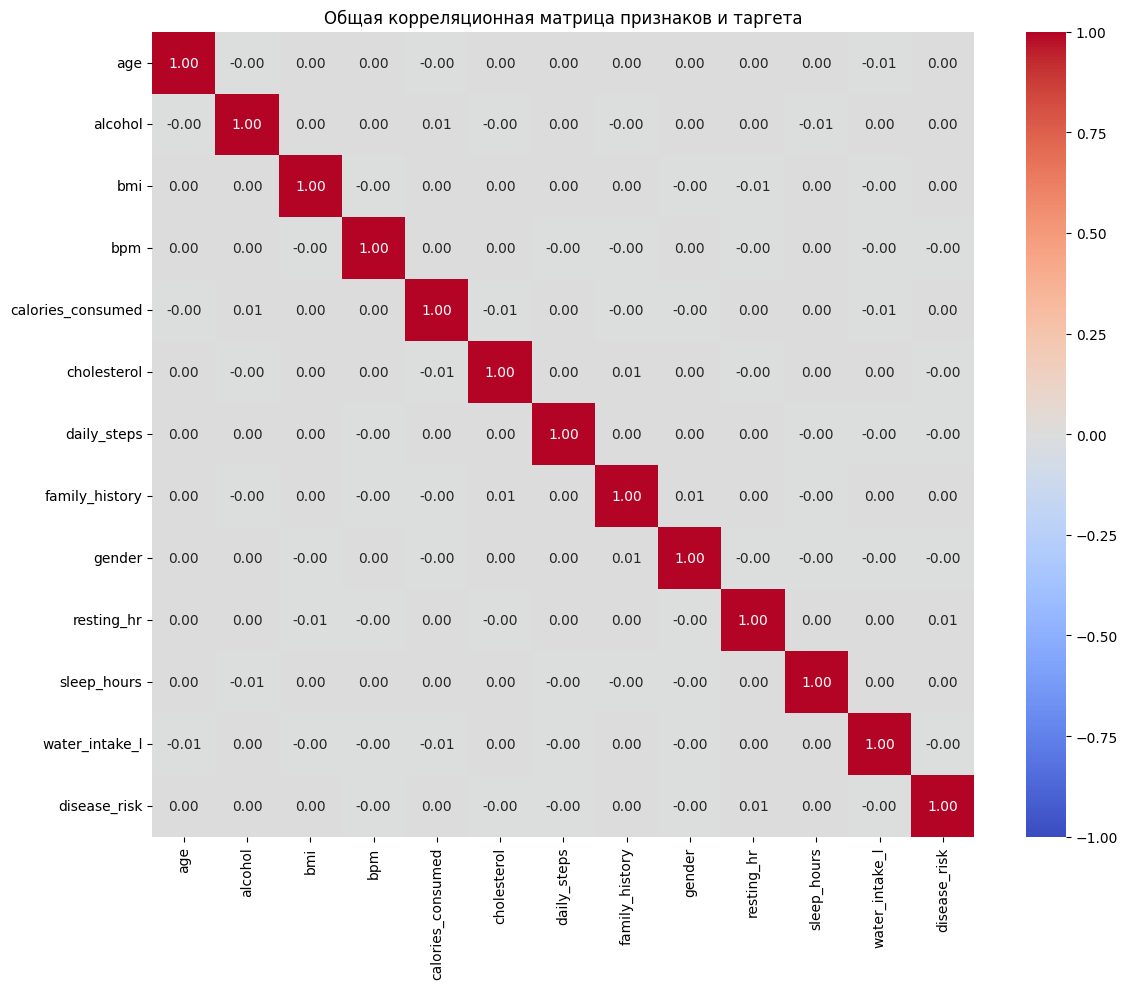

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target = 'disease_risk'
# Список всех признаков, которые были в группах
all_features = sorted(list({f for cols in groups.values() for f in cols}))
# Добавляю таргет
all_features_with_target = all_features + [target]
# Вычисляю корреляционную матрицу между всеми выбранными признаками и таргетом
corr_matrix = df_cleaned[all_features_with_target].corr()
# Строю heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Общая корреляционная матрица признаков и таргета')
plt.tight_layout()
plt.show()


Снова картина не радует. Я решила, что нужно придумать новый вариант: выявить те данные в disease_risk, где стоит цифра 1, посмотреть что влияет на это и какие данные соединились чтобы в disease_risk было 1, но сначала все эти данные привести к int

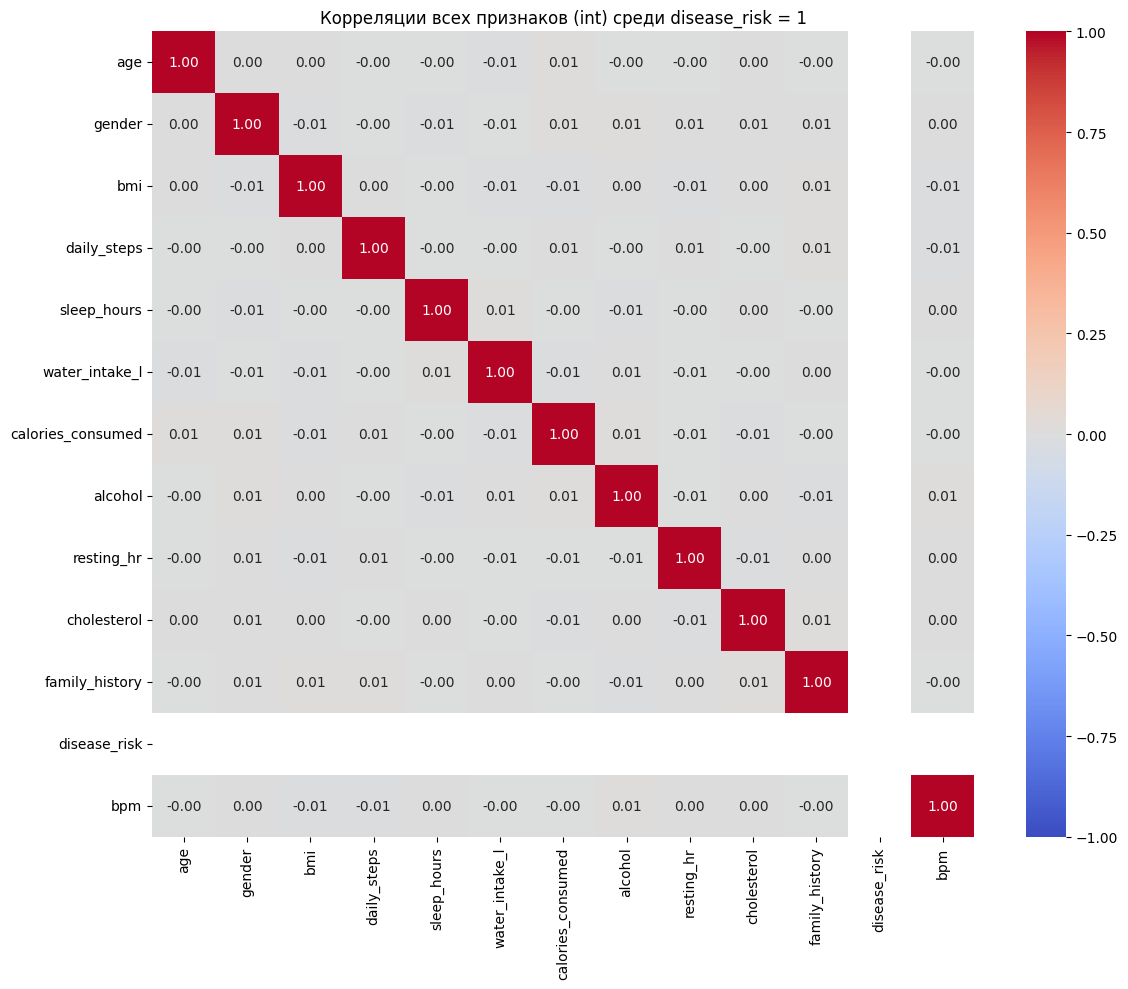

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Беру все строки, где disease_risk = 1
risk_1_df = df_cleaned[df_cleaned['disease_risk'] == 1].copy()

# Привожу все признаки к int
risk_1_int = risk_1_df.astype(int)

# Расчет корреляции
corr_risk_1_int = risk_1_int.corr()

# Визуализация heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_risk_1_int, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Корреляции всех признаков (int) среди disease_risk = 1')
plt.tight_layout()
plt.show()


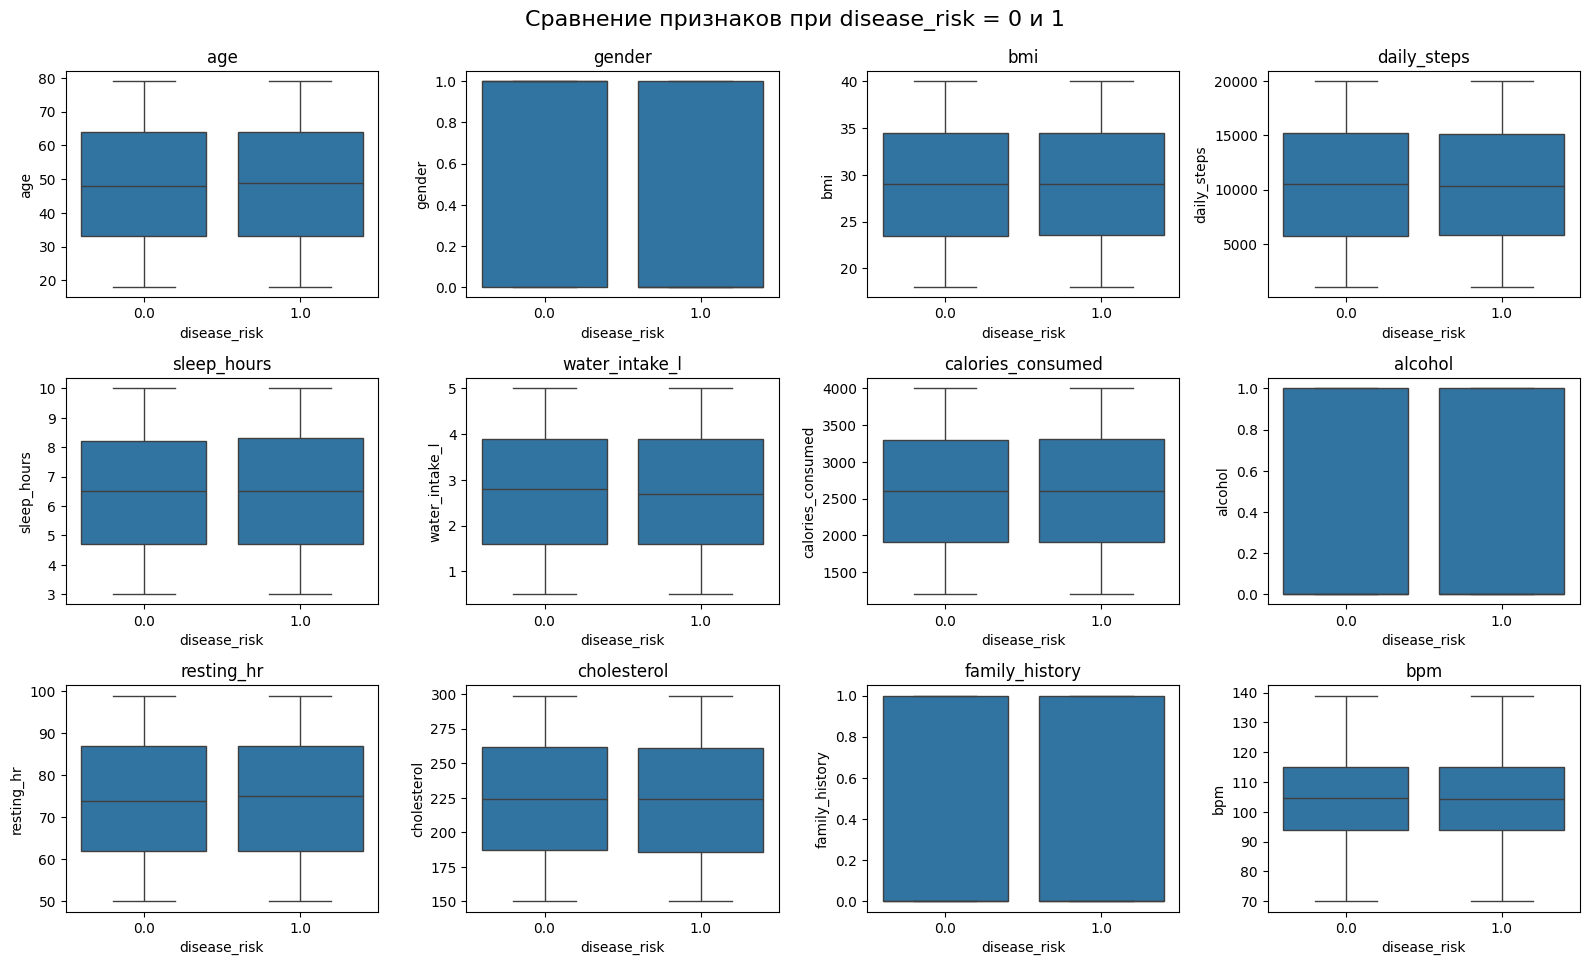

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Предположим, df_cleaned уже есть
target = 'disease_risk'

# Список всех признаков, кроме таргета
features = [col for col in df_cleaned.columns if col != target]

# Настройка размера фигуры
plt.figure(figsize=(16, 12))

# По каждому признаку прохожу и строю boxplot
for i, feature in enumerate(features, 1):
    plt.subplot(4, 4, i)  # 4x4 сетка (можно менять)
    sns.boxplot(x=target, y=feature, data=df_cleaned)
    plt.title(feature)
    plt.tight_layout()

plt.suptitle('Сравнение признаков при disease_risk = 0 и 1', fontsize=16, y=1.02)
plt.show()


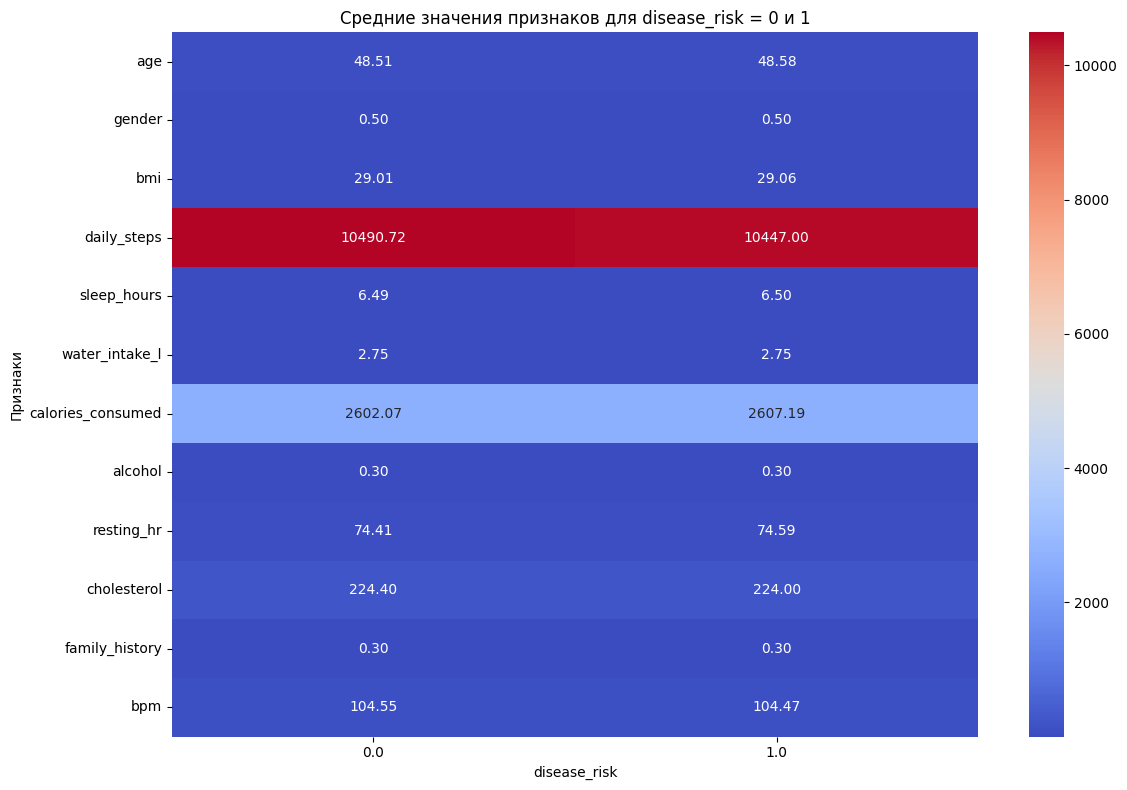

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Группировка по таргету и расчет среднего значения признаков
mean_features = df_cleaned.groupby('disease_risk').mean()

# Визуализация heatmap
plt.figure(figsize=(12,8))
sns.heatmap(mean_features.T, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Средние значения признаков для disease_risk = 0 и 1')
plt.ylabel('Признаки')
plt.xlabel('disease_risk')
plt.tight_layout()
plt.show()


Таким образом, мы видим что может хоть немного влиять на болезнь. Далее создаю новые фичи, которые помогут мне в дальнейшем

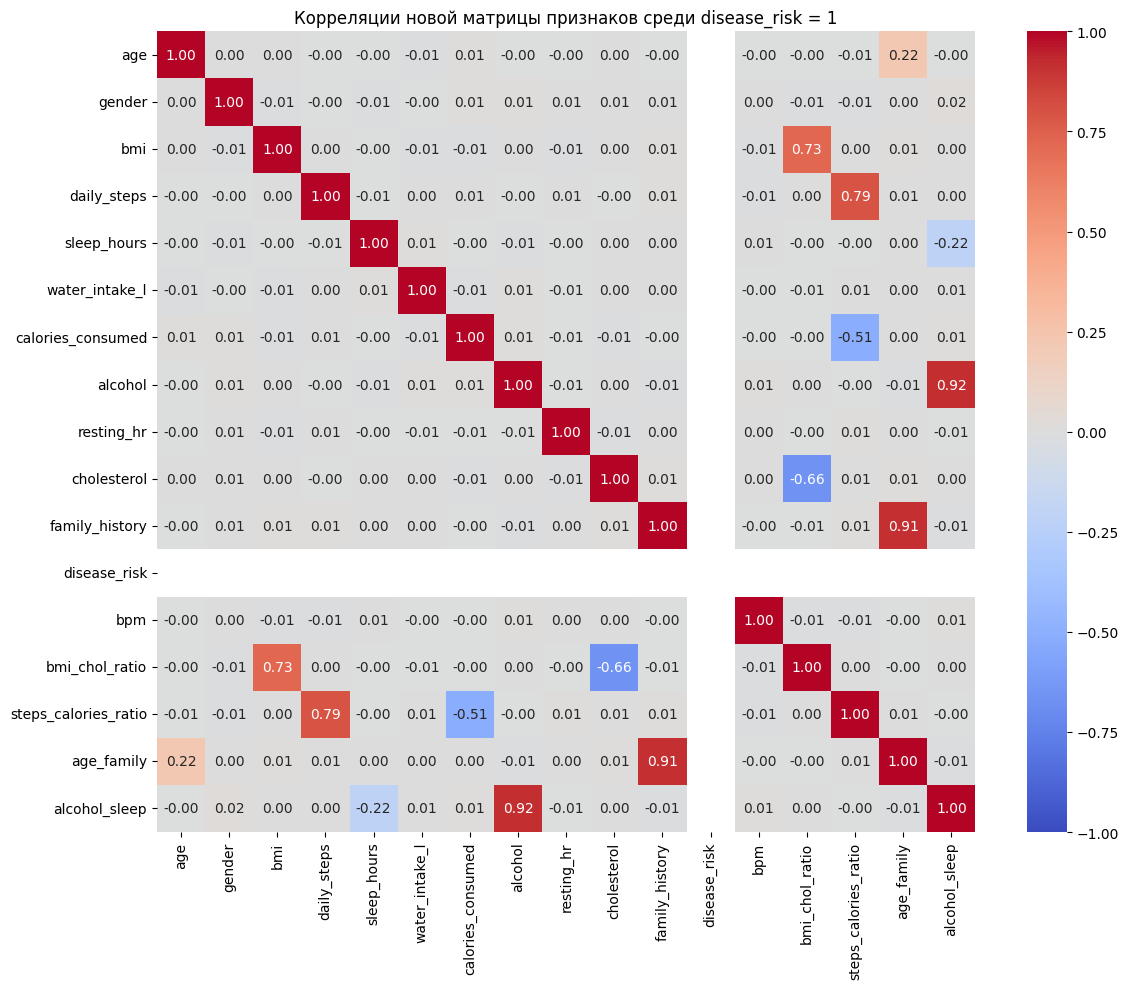

In [ ]:
df_features = df_cleaned.copy()

# Примеры новых фич
df_features['bmi_chol_ratio'] = df_features['bmi'] / (df_features['cholesterol'] + 1e-5)
df_features['steps_calories_ratio'] = df_features['daily_steps'] / (df_features['calories_consumed'] + 1e-5)
df_features['age_family'] = df_features['age'] * df_features['family_history']
df_features['alcohol_sleep'] = df_features['alcohol'] / (df_features['sleep_hours'] + 1e-5)

# Стандартизация числовых признаков для удобства
from sklearn.preprocessing import StandardScaler
numeric_cols = df_features.select_dtypes(include='number').columns.tolist()
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features[numeric_cols]), columns=numeric_cols)

# Строю heatmap новой матрицы признаков для disease_risk = 1
risk_1_scaled = df_scaled[df_features['disease_risk'] == 1]

plt.figure(figsize=(12,10))
sns.heatmap(risk_1_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Корреляции новой матрицы признаков среди disease_risk = 1')
plt.tight_layout()
plt.show()


Вот уже картинка стала складываться лучше,у нас появились сильные корреляции. Теперь их берем за основу, ищем фичи и делаем новую матрицу

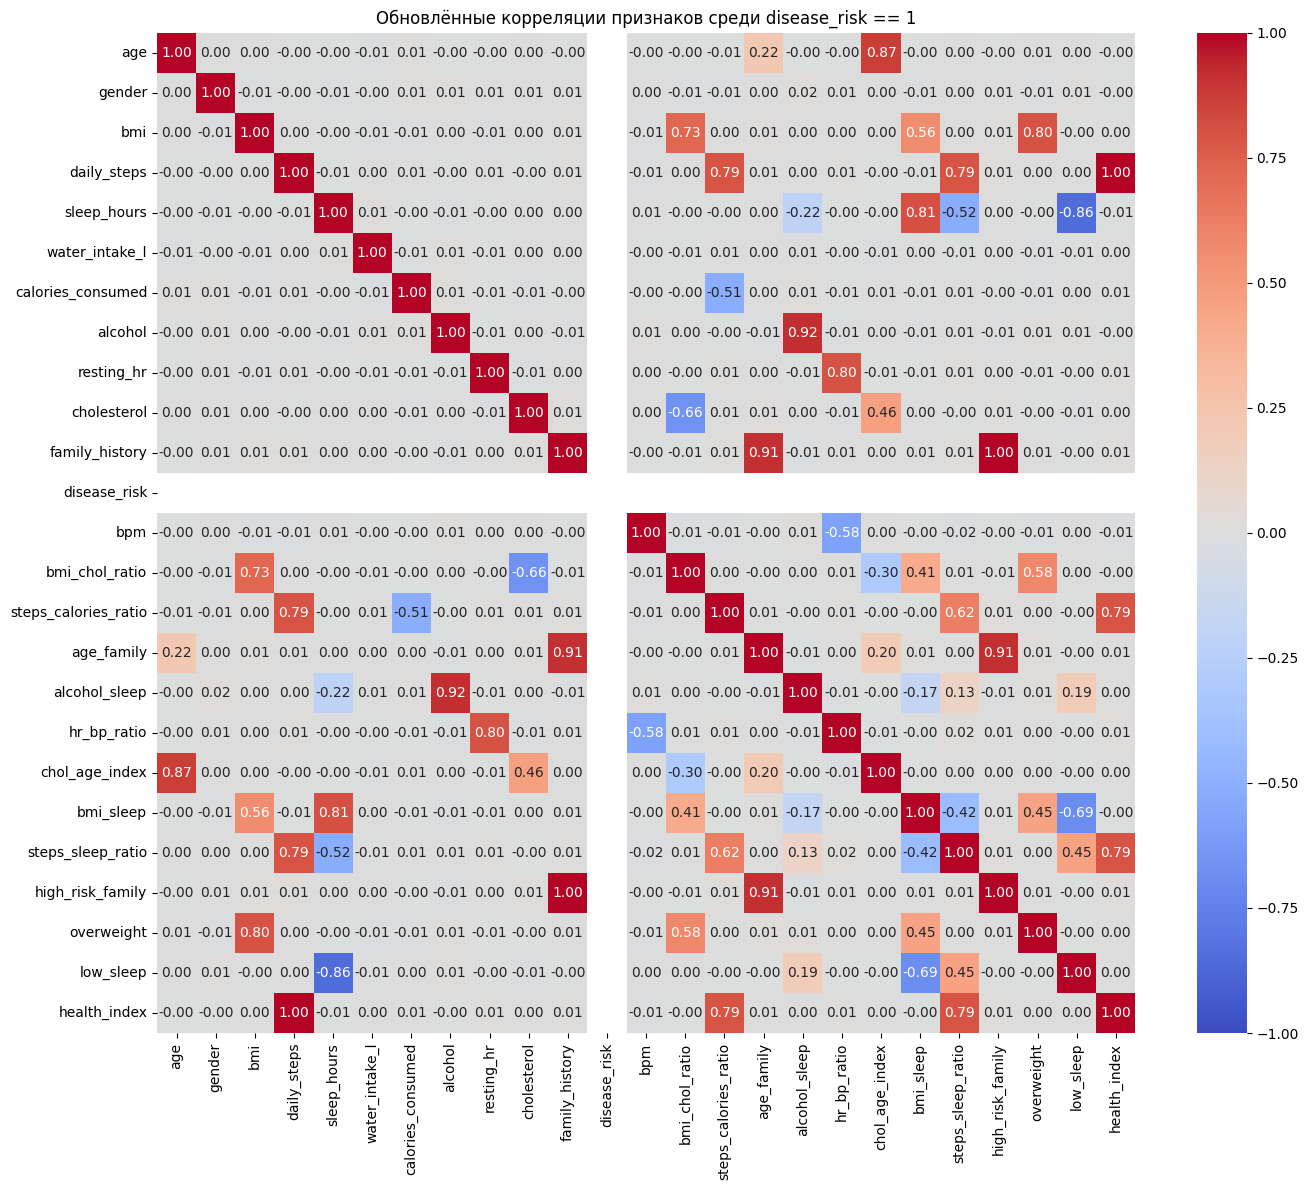

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Копирую очищенный датафрейм
df_features = df_cleaned.copy()

# Добавленные фичи
df_features['bmi_chol_ratio'] = df_features['bmi'] / (df_features['cholesterol'] + 1e-5)
df_features['steps_calories_ratio'] = df_features['daily_steps'] / (df_features['calories_consumed'] + 1e-5)
df_features['age_family'] = df_features['age'] * df_features['family_history']
df_features['alcohol_sleep'] = df_features['alcohol'] / (df_features['sleep_hours'] + 1e-5)

# Новые информативные фичи
df_features['hr_bp_ratio'] = df_features['resting_hr'] / (df_features['bpm'] + 1e-5)  # Используем bpm как давление
df_features['chol_age_index'] = df_features['cholesterol'] * df_features['age']
df_features['bmi_sleep'] = df_features['bmi'] * df_features['sleep_hours']
df_features['steps_sleep_ratio'] = df_features['daily_steps'] / (df_features['sleep_hours'] + 1e-5)

# Категориальные бинарные признаки
df_features['high_risk_family'] = (df_features['family_history'] > 0).astype(int)
df_features['overweight'] = (df_features['bmi'] >= 25).astype(int)
df_features['low_sleep'] = (df_features['sleep_hours'] < 6).astype(int)

# Суммарный "здоровый индекс"
health_cols = ['bmi', 'cholesterol', 'resting_hr', 'daily_steps']
df_features['health_index'] = df_features[health_cols].mean(axis=1)

# Стандартизация всех числовых признаков
numeric_cols = df_features.select_dtypes(include='number').columns.tolist()
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features[numeric_cols]), columns=numeric_cols)

risk_1_scaled = df_scaled[df_features['disease_risk'] == 1]

plt.figure(figsize=(14,12))
sns.heatmap(risk_1_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Обновлённые корреляции признаков среди disease_risk == 1')
plt.tight_layout()
plt.show()


Исходя из данных, мы можем выявить фичи, которые реально влияют на риск заболевания и можно идти дальше

In [ ]:
# Корреляционная матрица
corr_matrix = risk_1_scaled.corr()

# Список сильных зависимостей (|corr| >= 0.7), исключаем диагональ
strong_corrs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) >= 0.7:
            strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_value))

print("Сильные зависимости (|corr| >= 0.7):")
for pair in strong_corrs:
    print(f"{pair[0]} ↔ {pair[1]} : {pair[2]:.2f}")


Сильные зависимости (|corr| >= 0.7):
age ↔ chol_age_index : 0.87
bmi ↔ bmi_chol_ratio : 0.73
bmi ↔ overweight : 0.80
daily_steps ↔ steps_calories_ratio : 0.79
daily_steps ↔ steps_sleep_ratio : 0.79
daily_steps ↔ health_index : 1.00
sleep_hours ↔ bmi_sleep : 0.81
sleep_hours ↔ low_sleep : -0.86
alcohol ↔ alcohol_sleep : 0.92
resting_hr ↔ hr_bp_ratio : 0.80
family_history ↔ age_family : 0.91
family_history ↔ high_risk_family : 1.00
steps_calories_ratio ↔ health_index : 0.79
age_family ↔ high_risk_family : 0.91
steps_sleep_ratio ↔ health_index : 0.79


делаю новый EDA: распределяю числовые признаки, сравнниваю классы для
бинарных и новых фич, готовлю финальный датафрейм для модели

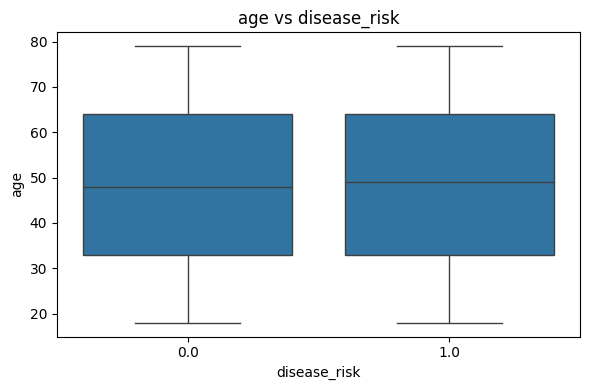

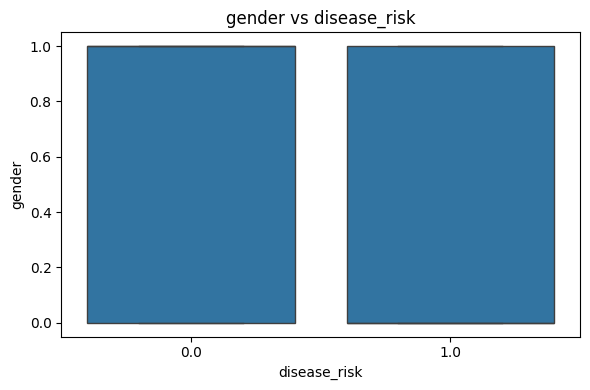

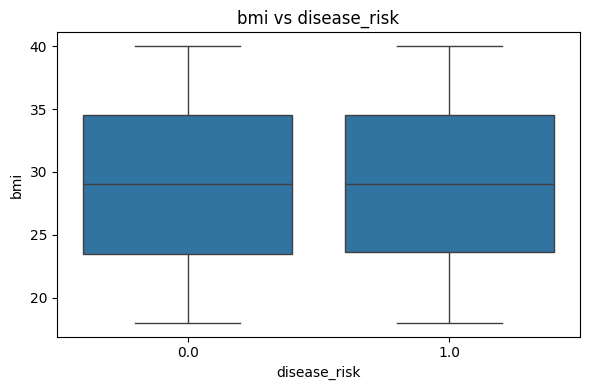

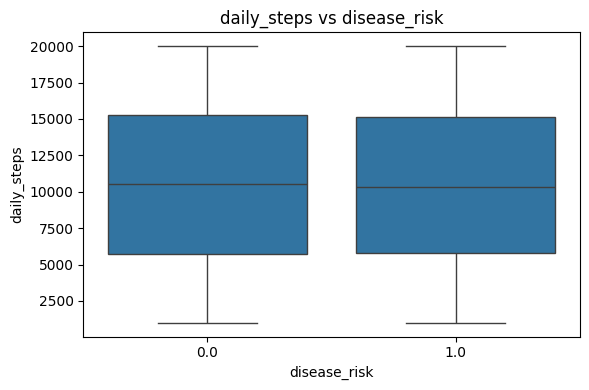

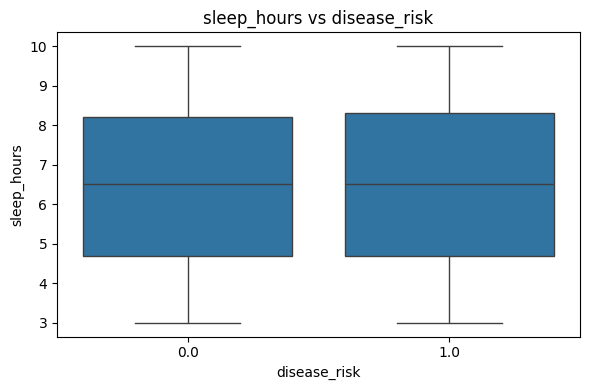

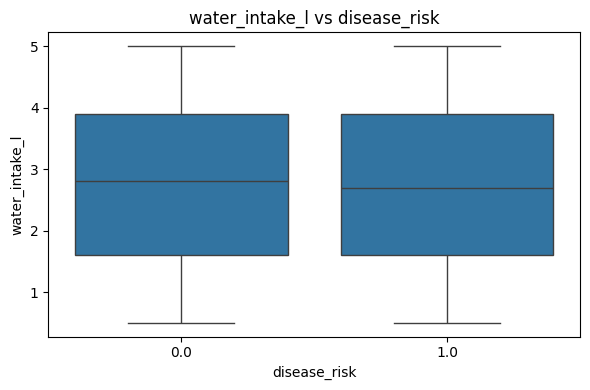

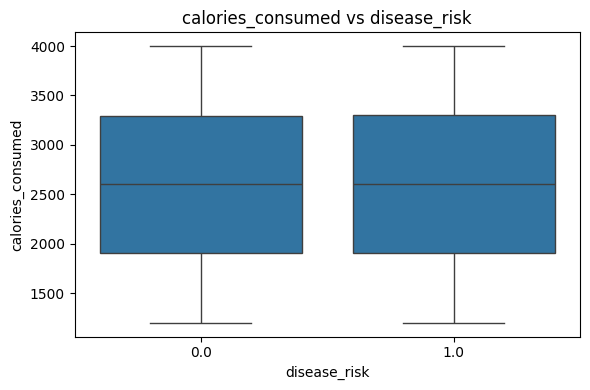

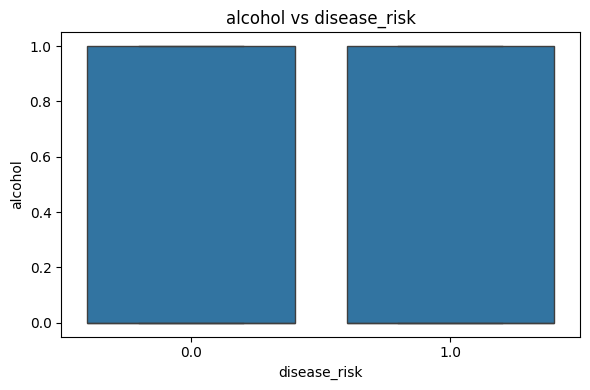

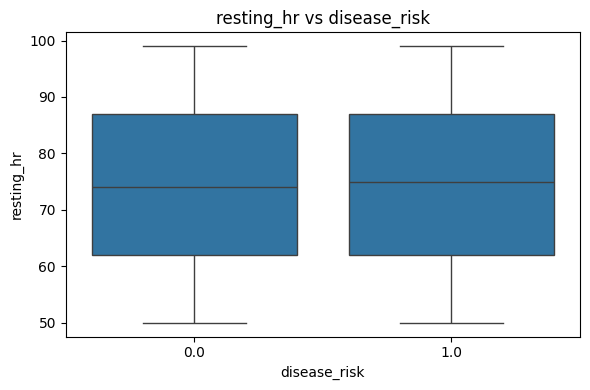

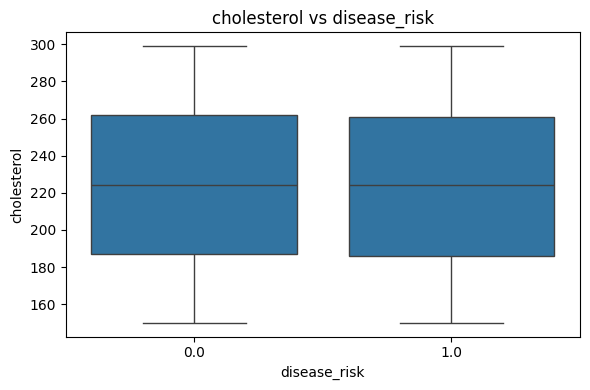

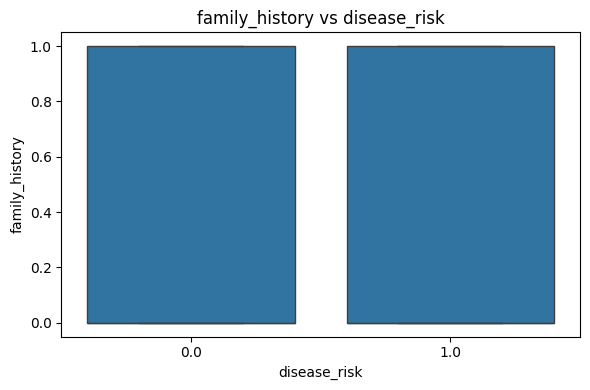

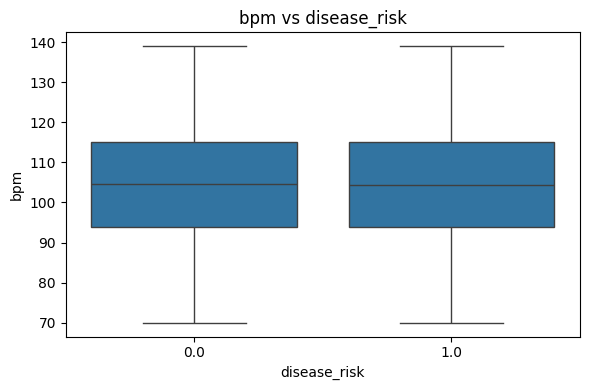

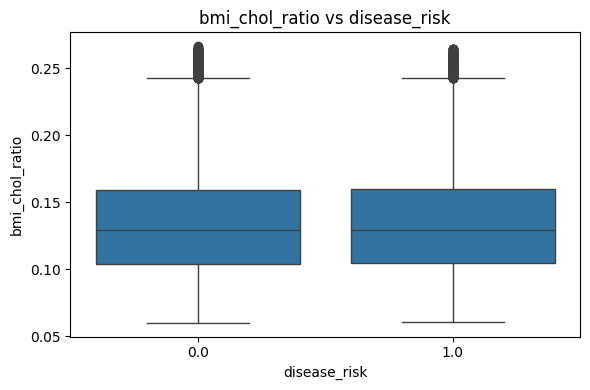

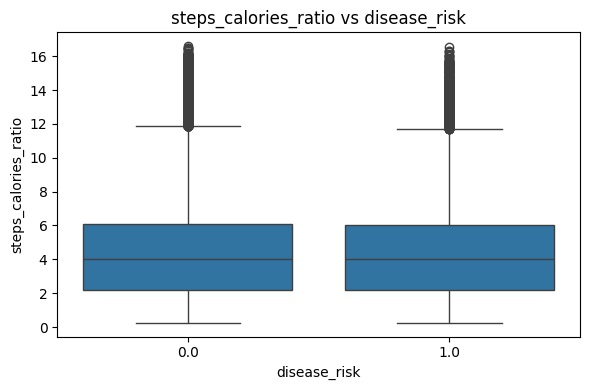

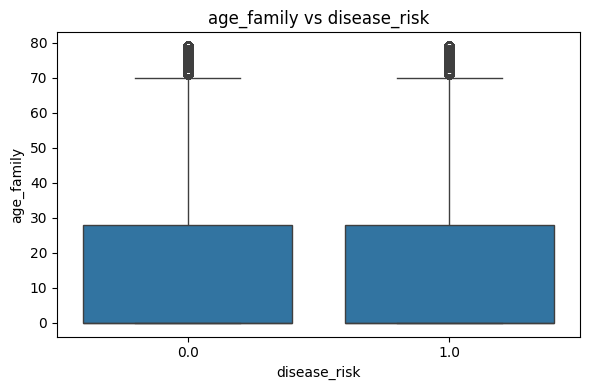

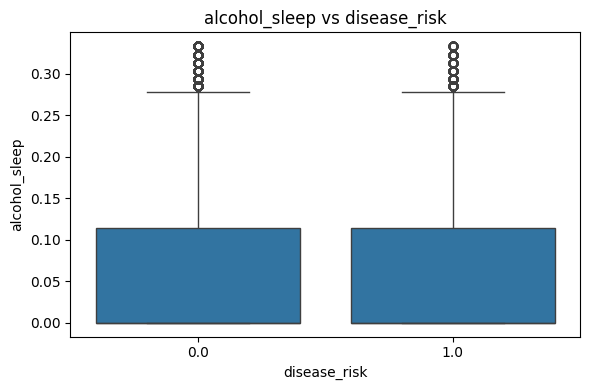

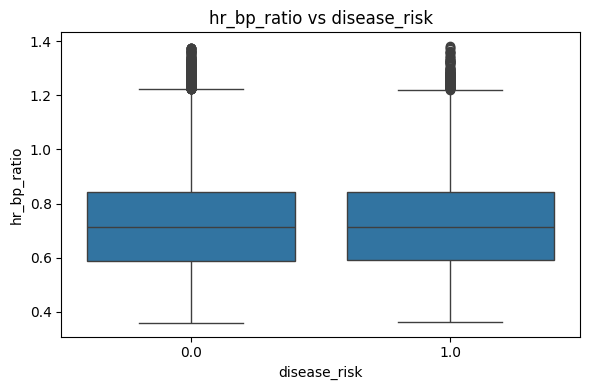

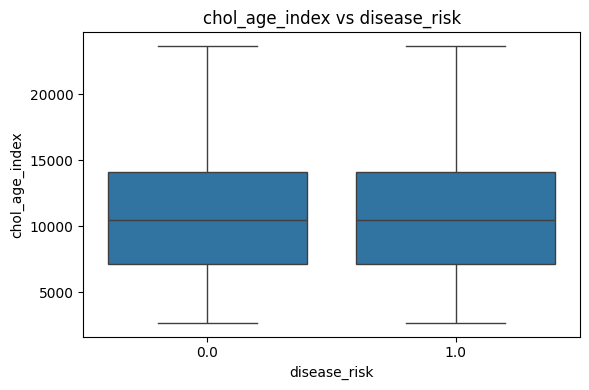

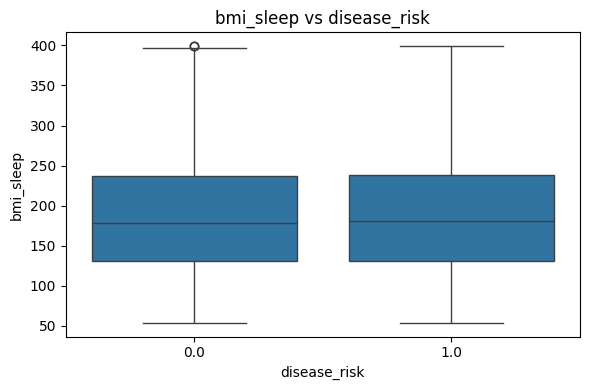

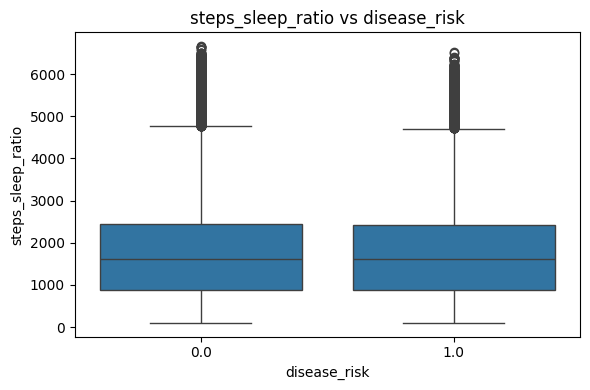

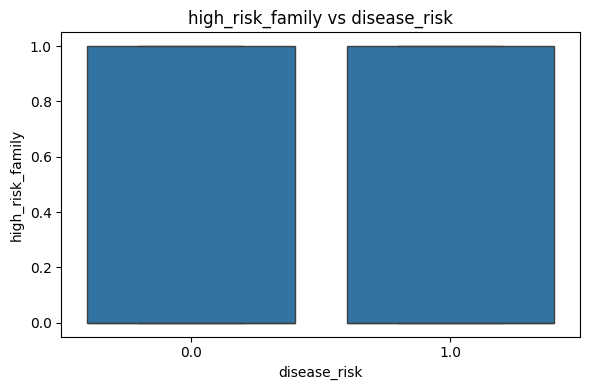

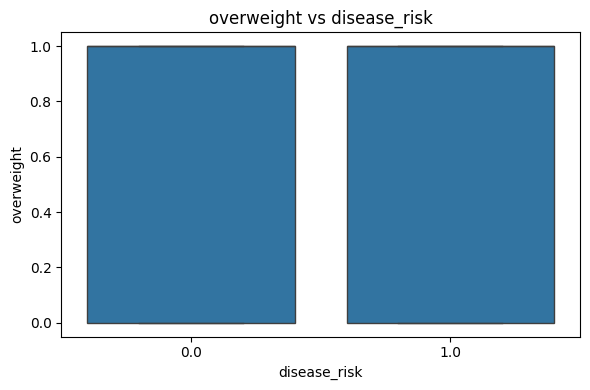

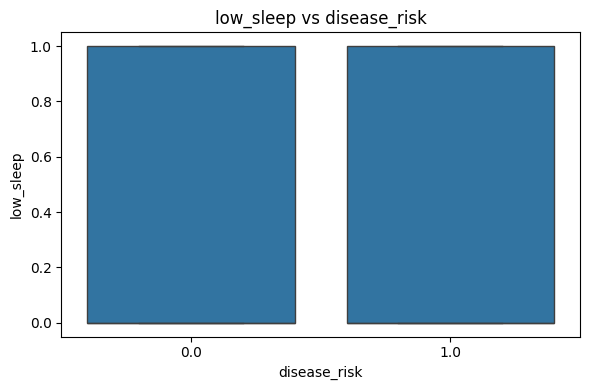

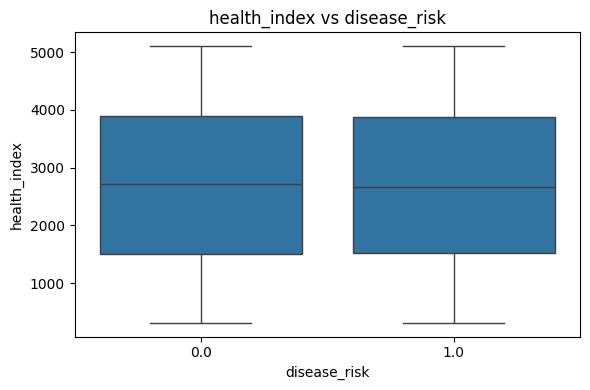

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Числовые признаки, исключая таргет
num_features = df_features.select_dtypes(include='number').columns.tolist()
num_features.remove('disease_risk')

# Boxplot по каждому признаку для двух классов disease_risk
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_features['disease_risk'], y=df_features[col])
    plt.title(f'{col} vs disease_risk')
    plt.xlabel('disease_risk')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


Сравниваем категориальные и бинарные признаки

In [ ]:
# Список бинарных признаков
binary_features = ['high_risk_family', 'overweight', 'low_sleep']

for col in binary_features:
    ct = pd.crosstab(df_features[col], df_features['disease_risk'], normalize='columns')
    print(f"\nРаспределение {col} по disease_risk:")
    print(ct)



Распределение high_risk_family по disease_risk:
disease_risk           0.0      1.0
high_risk_family                   
0                 0.701699  0.69828
1                 0.298301  0.30172

Распределение overweight по disease_risk:
disease_risk      0.0       1.0
overweight                     
0             0.31546  0.308811
1             0.68454  0.691189

Распределение low_sleep по disease_risk:
disease_risk       0.0       1.0
low_sleep                       
0             0.574801  0.580033
1             0.425199  0.419967


Финальная матрица признаков

In [ ]:
# Выбираю все числовые и бинарные признаки
model_features = num_features + binary_features

# Финальный датафрейм для модели
X = df_features[model_features]
y = df_features['disease_risk']

# Проверка формы
print(f'Финальный X: {X.shape}, y: {y.shape}')


Финальный X: (100000, 27), y: (100000,)


Переходим к обучению модели

In [ ]:
from sklearn.model_selection import train_test_split

# 80% для обучения, 20% для теста
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')


Train: (80000, 27), Test: (20000, 27)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importances:\n", importances)


Feature Importances:
 calories_consumed       0.064036
hr_bp_ratio             0.063924
chol_age_index          0.062630
bmi_chol_ratio          0.062341
steps_calories_ratio    0.061942
bmi_sleep               0.061240
steps_sleep_ratio       0.060095
bpm                     0.059427
health_index            0.057924
daily_steps             0.057142
bmi                     0.056081
cholesterol             0.055937
water_intake_l          0.053394
resting_hr              0.049245
age                     0.047630
sleep_hours             0.046259
alcohol_sleep           0.021171
age_family              0.019432
gender                  0.009445
alcohol                 0.006009
high_risk_family        0.004291
high_risk_family        0.004239
family_history          0.004225
overweight              0.003060
low_sleep               0.003024
overweight              0.002962
low_sleep               0.002896
dtype: float64


Обучаю модель.

Выбираю лучшую модель

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Уменьшение выборки
X_sample = X.sample(10000, random_state=42)
y_sample = y.loc[X_sample.index]

# Настройки
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Кросс-валидация
results = []
for name, model in models.items():
    auc_scores = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='roc_auc', n_jobs=-1)
    acc_scores = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='accuracy', n_jobs=-1)
    results.append({
        "Model": name,
        "Mean ROC-AUC": np.mean(auc_scores),
        "Std ROC-AUC": np.std(auc_scores),
        "Mean Accuracy": np.mean(acc_scores)
    })

results_df = pd.DataFrame(results).sort_values(by="Mean ROC-AUC", ascending=False)
print("📊 Результаты кросс-валидации (ускоренная версия):\n")
print(results_df.round(3))


📊 Результаты кросс-валидации (ускоренная версия):

                 Model  Mean ROC-AUC  Std ROC-AUC  Mean Accuracy
1        Random Forest         0.499        0.007          0.752
2    Gradient Boosting         0.493        0.010          0.751
0  Logistic Regression         0.490        0.004          0.755


Пытаюсь понять почему такие значения

Балансирую классы, применяю балансировку (oversampling/undersampling) через SMOTE

In [ ]:
y.value_counts(normalize=True)

,proportion
disease_risk,
0.0,0.75179
1.0,0.24821


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)
print(y_bal.value_counts())

disease_risk
0.0    75179
1.0    75179
Name: count, dtype: int64


Обучаем снова после балансировки

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd
import numpy as np

# Настройки кросс-валидации
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Модели
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Кросс-валидация на сбалансированных данных
results_bal = []
for name, model in models.items():
    auc_scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring='roc_auc', n_jobs=-1)
    acc_scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring='accuracy', n_jobs=-1)
    results_bal.append({
        "Model": name,
        "Mean ROC-AUC": np.mean(auc_scores),
        "Std ROC-AUC": np.std(auc_scores),
        "Mean Accuracy": np.mean(acc_scores)
    })

results_bal_df = pd.DataFrame(results_bal).sort_values(by="Mean ROC-AUC", ascending=False)
print("📊 Результаты после балансировки (SMOTE):\n")
print(results_bal_df.round(3))


📊 Результаты после балансировки (SMOTE):

                 Model  Mean ROC-AUC  Std ROC-AUC  Mean Accuracy
1        Random Forest         0.844        0.001          0.816
2    Gradient Boosting         0.822        0.002          0.797
0  Logistic Regression         0.673        0.002          0.612


Random Forest показала наилучший результат, теперь можно понять, почему модель принимает решения и какие признаки влияют сильнее всего. Поэтому применю Feature Importance на лучшем результате - Random Forest.

/tmp/ipython-input-4244044759.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(15), y=importances.head(15).index, palette="coolwarm")


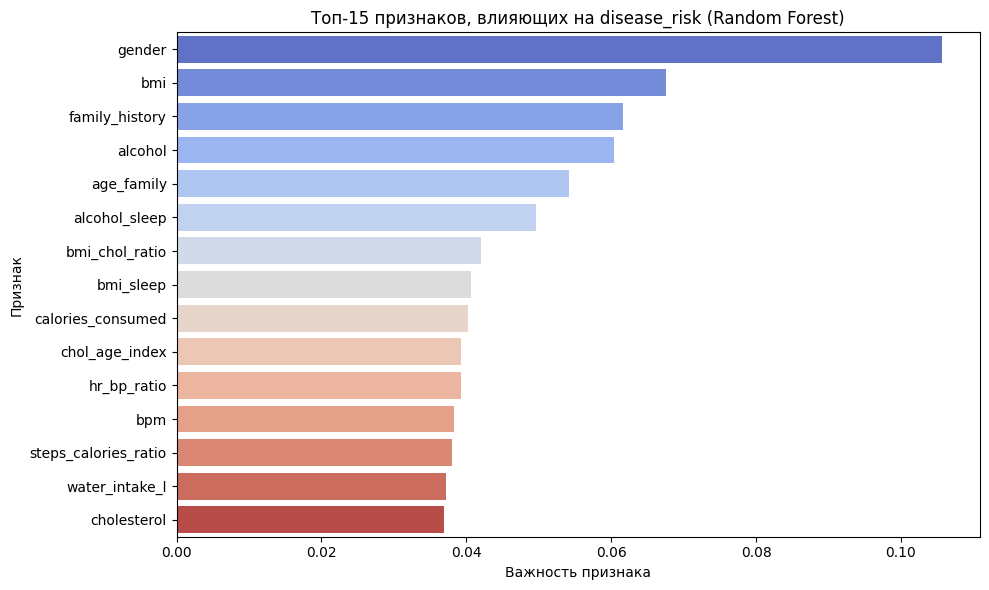

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest
best_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
best_model.fit(X_bal, y_bal)

# Важность признаков
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Визуализация топ-15
plt.figure(figsize=(10,6))
sns.barplot(x=importances.head(15), y=importances.head(15).index, palette="coolwarm")
plt.title('Топ-15 признаков, влияющих на disease_risk (Random Forest)')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2316165706.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_bal, y=X_bal[feature], ax=axes[i,0], palette="Set2")
/tmp/ipython-input-2316165706.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y_bal, y=X_bal[feature], ax=axes[i,1], palette="Set3")
/tmp/ipython-input-2316165706.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_bal, y=X_bal[feature], ax=axes[i,0], palette="Set2")
/tmp/ipython-input-2316165706.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

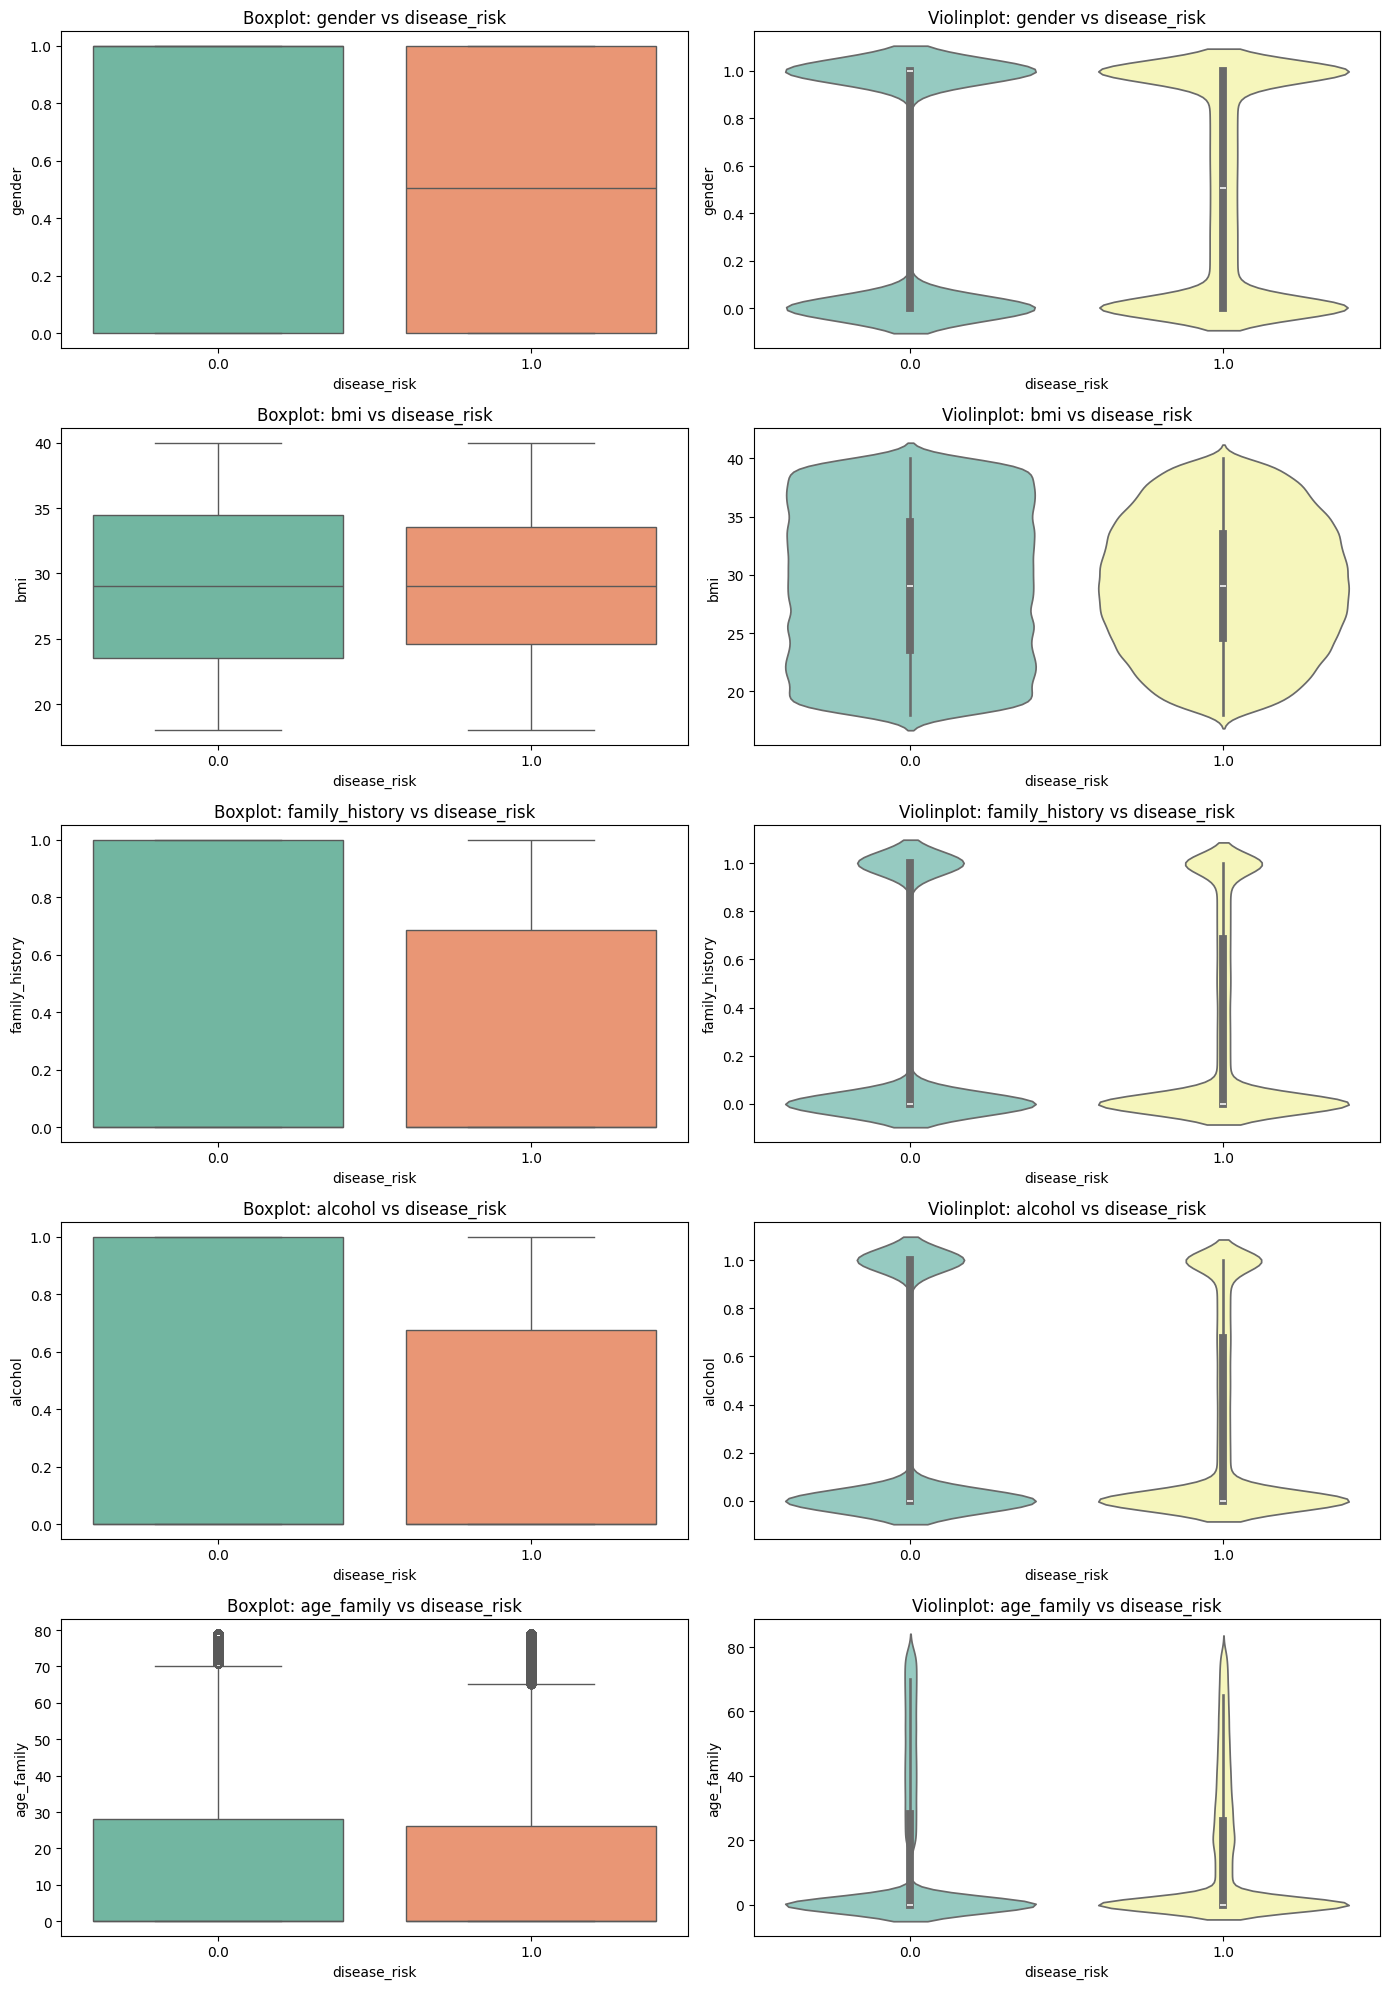

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Топ-5 признаков
top5 = importances.head(5).index.tolist()

# Создаю subplots
fig, axes = plt.subplots(len(top5), 2, figsize=(14, 4*len(top5)))

for i, feature in enumerate(top5):
    # Boxplot
    sns.boxplot(x=y_bal, y=X_bal[feature], ax=axes[i,0], palette="Set2")
    axes[i,0].set_title(f'Boxplot: {feature} vs disease_risk')
    axes[i,0].set_xlabel('disease_risk')
    axes[i,0].set_ylabel(feature)

    # Violinplot
    sns.violinplot(x=y_bal, y=X_bal[feature], ax=axes[i,1], palette="Set3")
    axes[i,1].set_title(f'Violinplot: {feature} vs disease_risk')
    axes[i,1].set_xlabel('disease_risk')
    axes[i,1].set_ylabel(feature)

plt.tight_layout()
plt.show()


Финальный отчет

/tmp/ipython-input-3051789482.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_bal, y=X_bal[feature], ax=axes[i,0], palette="Set2")
/tmp/ipython-input-3051789482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y_bal, y=X_bal[feature], ax=axes[i,1], palette="Set3")
/tmp/ipython-input-3051789482.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_bal, y=X_bal[feature], ax=axes[i,0], palette="Set2")
/tmp/ipython-input-3051789482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

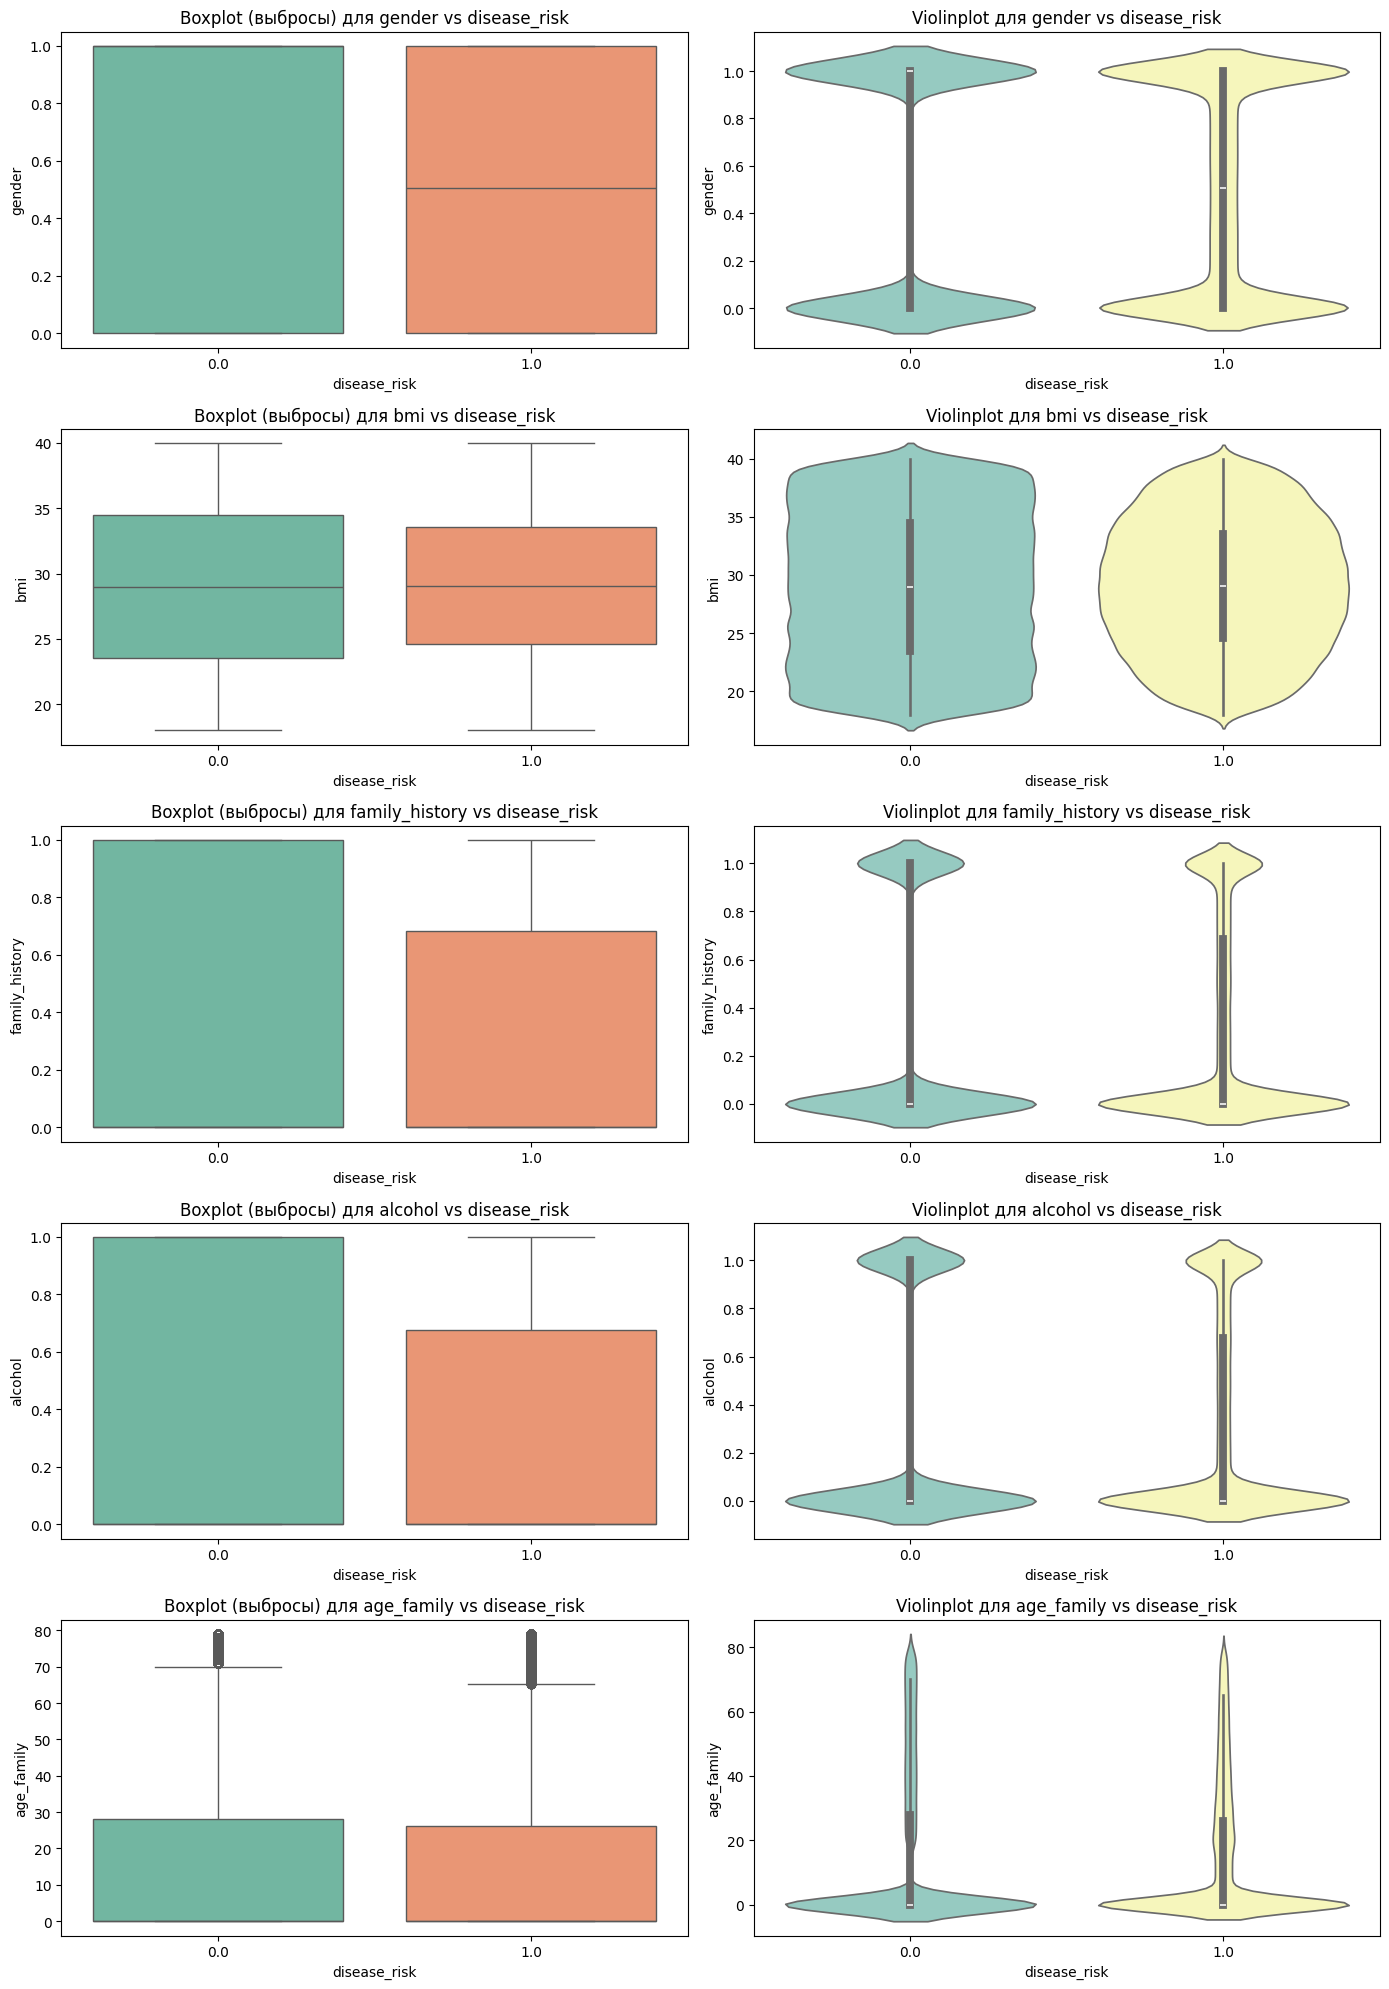

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Топ-5 признаков по важности
top5 = importances.head(5).index.tolist()

fig, axes = plt.subplots(len(top5), 2, figsize=(14, 4*len(top5)))

for i, feature in enumerate(top5):
    # Boxplot (выделяет выбросы)
    sns.boxplot(x=y_bal, y=X_bal[feature], ax=axes[i,0], palette="Set2")
    axes[i,0].set_title(f'Boxplot (выбросы) для {feature} vs disease_risk')
    axes[i,0].set_xlabel('disease_risk')
    axes[i,0].set_ylabel(feature)

    # Violinplot (показывает распределение и плотность)
    sns.violinplot(x=y_bal, y=X_bal[feature], ax=axes[i,1], palette="Set3")
    axes[i,1].set_title(f'Violinplot для {feature} vs disease_risk')
    axes[i,1].set_xlabel('disease_risk')
    axes[i,1].set_ylabel(feature)

plt.tight_layout()
plt.show()

In [43]:
#делаю еще один файл cvs  для дашборда, произвожу раскодировку признаков
import pandas as pd

df = pd.read_csv('/content/health_lifestyle_dataset.csv')

# Проверим, какие колонки доступны
print("Колонки в датасете:", df.columns.tolist())

# Добавляем вычисляемые признаки
if 'bpm' in df.columns and 'resting_hr' in df.columns:
    df['pressure_index'] = df['bpm'] / df['resting_hr']
elif {'systolic_bp', 'diastolic_bp', 'resting_hr'}.issubset(df.columns):
    df['bpm'] = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3
    df['pressure_index'] = df['bpm'] / df['resting_hr']
else:
    df['pressure_index'] = None  # если нет данных для расчёта

# Остальные признаки
df['activity_efficiency'] = df['daily_steps'] / (df['calories_consumed'] + 1e-5)
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 70, 100],
                         labels=['young', 'middle', 'senior', 'elder'])

# Сохраняем финальный датасет
df.to_csv('final_health_dashboard.csv', index=False)

print("\n Финальный датасет успешно сохранён!")
print(df.head())



Колонки в датасете: ['id', 'age', 'gender', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l', 'calories_consumed', 'alcohol', 'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'family_history', 'disease_risk']

✅ Финальный датасет успешно сохранён!
   id  age  gender   bmi  daily_steps  sleep_hours  water_intake_l  \
0   1   56    Male  20.5         4198          3.9             3.4   
1   2   69  Female  33.3        14359          9.0             4.7   
2   3   46    Male  31.6         1817          6.6             4.2   
3   4   32  Female  38.2        15772          3.6             2.0   
4   5   60  Female  33.6         6037          3.8             4.0   

   calories_consumed  alcohol  resting_hr  systolic_bp  diastolic_bp  \
0               1602        0          97          161           111   
1               2346        1          68          116            65   
2               1643        1          90          123            99   
3               2460       